# GPU-Accelerated CMA-ES Deconvolution

Interactive single-gene deconvolution using the GPU TASEP kernel.

Features:
- **Warm-start** from analytical flux correction (Eq. M3)
- **Multi-fidelity N_RUNS** (200/400/600 as sigma decreases)
- **Early stopping** on convergence plateau
- **GPU dispatch** via `netseq_tasep_gpu.objective_batch_gpu`

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time

from netseq_tasep_fast import _load_gene_parameters, netseq_tasep_fast
from netseq_tasep_gpu import objective_batch_gpu, cuda_is_available, gpu_count
from cmaes_multifidelity import (
    j_analytical, warm_start_theta,
    CMAESConfig, NRunsSchedule, EarlyStopping,
    run_cmaes_for_gene,
)

print(f"CUDA available: {cuda_is_available()}")
print(f"GPU count: {gpu_count()}")

CUDA available: True
GPU count: 2


## Configuration

In [2]:
GENE = "insQ"

# Load gene data
base_params = _load_gene_parameters(GENE)
S_exp_norm = base_params["RNAP_dwellTimeProfile"].copy()
gene_length = len(S_exp_norm)

print(f"Gene: {GENE}")
print(f"Gene length: {gene_length} bp")
print(f"KRutLoading: {base_params['KRutLoading']}")
print(f"kRiboLoading: {base_params['kRiboLoading']:.4f}")

Gene: insQ
Gene length: 1149 bp
KRutLoading: 0.13
kRiboLoading: 0.0220


## Warm-Start Visualization

Compare naive initialization ($D^0 = S_\text{exp}$) vs warm-start ($D^0 = S_\text{exp} / j_\text{analytical}$).

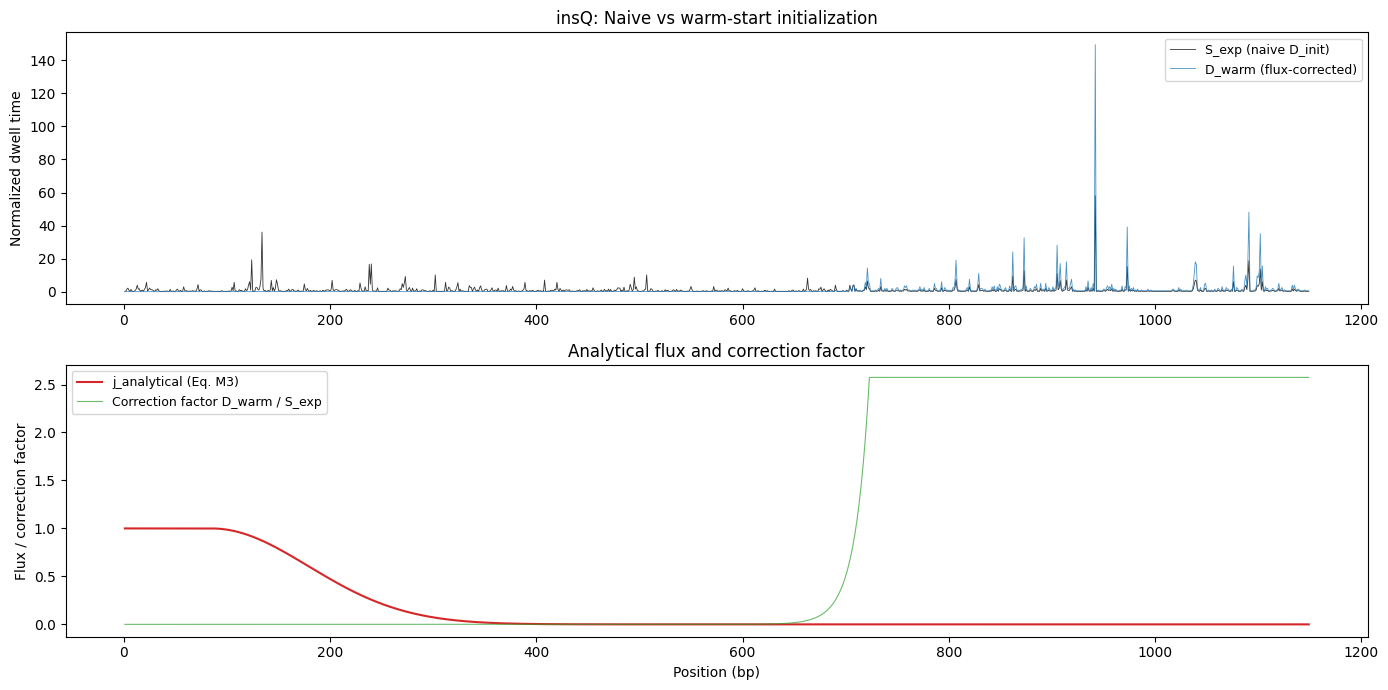

In [3]:
pos = np.arange(1, gene_length + 1)

# Analytical flux
j_anal = j_analytical(pos, base_params["KRutLoading"], gene_length)

# Warm-start D_init
theta_warm = warm_start_theta(S_exp_norm, base_params["KRutLoading"], gene_length)
D_warm = np.exp(theta_warm)
D_warm_norm = D_warm / np.mean(D_warm)

# Naive D_init
D_naive = S_exp_norm.copy()

fig, axes = plt.subplots(2, 1, figsize=(14, 7))

axes[0].plot(pos, S_exp_norm, lw=0.6, color="black", label="S_exp (naive D_init)", alpha=0.8)
axes[0].plot(pos, D_warm_norm, lw=0.6, color="tab:blue", label="D_warm (flux-corrected)", alpha=0.8)
axes[0].set_ylabel("Normalized dwell time")
axes[0].set_title(f"{GENE}: Naive vs warm-start initialization")
axes[0].legend(fontsize=9)

axes[1].plot(pos, j_anal, lw=1.5, color="tab:red", label="j_analytical (Eq. M3)")
axes[1].plot(pos, D_warm_norm / np.maximum(S_exp_norm, 1e-6), lw=0.8, color="tab:green",
             alpha=0.7, label="Correction factor D_warm / S_exp")
axes[1].set_xlabel("Position (bp)")
axes[1].set_ylabel("Flux / correction factor")
axes[1].set_title("Analytical flux and correction factor")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

## Run CMA-ES (GPU-accelerated)

Uses `run_cmaes_for_gene` with warm-start, multi-fidelity N_RUNS, and early stopping.

In [4]:
config = CMAESConfig(
    sigma0=0.1,
    max_generations=500,
    cma_seed=67,
    use_warm_start=True,
    use_gpu=True,   # Falls back to CPU if no CUDA
    n_runs_schedule=NRunsSchedule(
        n_runs_low=200,
        n_runs_med=400,
        n_runs_high=600,
    ),
    early_stopping=EarlyStopping(window=50, rel_threshold=0.005),
    checkpoint_dir="cmaes_checkpoints_gpu",
)

print("Running CMA-ES...")
t0 = time.time()
result = run_cmaes_for_gene(GENE, config=config, device_id=0)
elapsed = time.time() - t0

print(f"\nDone in {elapsed:.1f}s ({result['generations']} generations)")
print(f"Early stopped: {result['early_stopped']}")
print(f"Final MSE: {result['final_mse']:.6f}")
print(f"Final RMS: {result['final_rms']:.4f}")

Running CMA-ES...


/home/racda/Downloads/netseq-tasep/lib/python3.12/site-packages/numba/cuda/dispatcher.py:536: NumbaPerformanceWarning: Grid size 79 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))


  gen    1 | f_best=9.354978 | f_med=10.393900 | sigma=0.1011 | n_runs=200 | 9s | ETA 4309s
  gen    2 | f_best=9.079161 | f_med=10.275256 | sigma=0.1039 | n_runs=200 | 15s | ETA 3843s
  gen    3 | f_best=9.079161 | f_med=10.361795 | sigma=0.1079 | n_runs=200 | 22s | ETA 3686s
  gen    4 | f_best=8.980522 | f_med=10.048571 | sigma=0.1125 | n_runs=200 | 29s | ETA 3611s
  gen    5 | f_best=8.518954 | f_med=9.701043 | sigma=0.1178 | n_runs=200 | 36s | ETA 3549s
  gen    6 | f_best=8.518954 | f_med=9.869064 | sigma=0.1238 | n_runs=200 | 43s | ETA 3506s
  gen    7 | f_best=8.518954 | f_med=9.484299 | sigma=0.1289 | n_runs=200 | 49s | ETA 3475s
  gen    8 | f_best=8.518954 | f_med=9.496643 | sigma=0.1344 | n_runs=200 | 56s | ETA 3449s
  gen    9 | f_best=8.518954 | f_med=9.508481 | sigma=0.1402 | n_runs=200 | 63s | ETA 3425s
  gen   10 | f_best=8.426786 | f_med=9.142357 | sigma=0.1466 | n_runs=200 | 70s | ETA 3410s
  gen   11 | f_best=8.203095 | f_med=8.820874 | sigma=0.1529 | n_runs=200 | 7

## Convergence Analysis

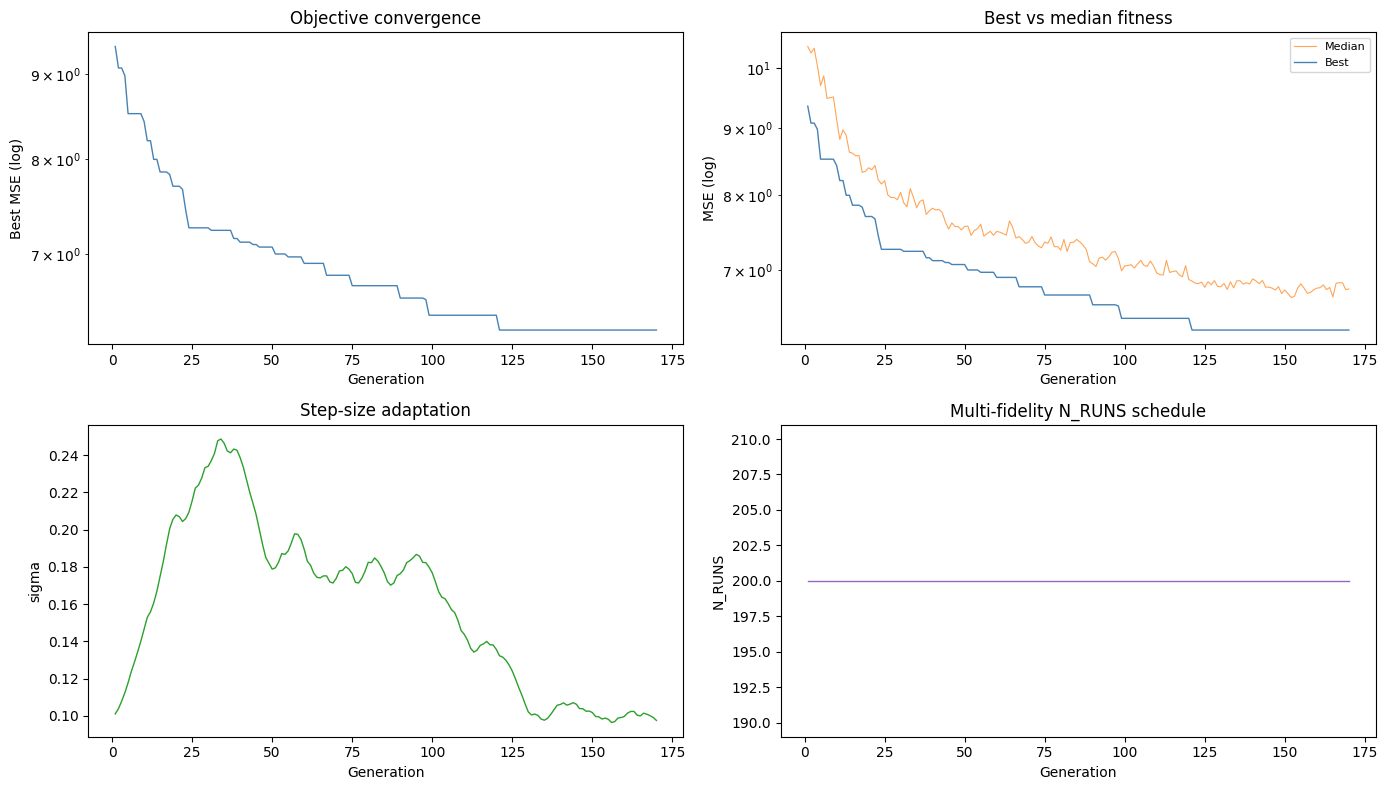

In [5]:
history = result["history"]
gens = np.array(history["gen"])

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Best objective
axes[0, 0].semilogy(gens, history["f_best"], "-", color="steelblue", lw=1)
axes[0, 0].set_xlabel("Generation")
axes[0, 0].set_ylabel("Best MSE (log)")
axes[0, 0].set_title("Objective convergence")

# Best vs median
axes[0, 1].semilogy(gens, history["f_median"], "-", color="tab:orange", lw=0.8, alpha=0.7, label="Median")
axes[0, 1].semilogy(gens, history["f_best"], "-", color="steelblue", lw=1, label="Best")
axes[0, 1].set_xlabel("Generation")
axes[0, 1].set_ylabel("MSE (log)")
axes[0, 1].set_title("Best vs median fitness")
axes[0, 1].legend(fontsize=8)

# Sigma
axes[1, 0].plot(gens, history["sigma"], "-", color="tab:green", lw=1)
axes[1, 0].set_xlabel("Generation")
axes[1, 0].set_ylabel("sigma")
axes[1, 0].set_title("Step-size adaptation")

# N_RUNS schedule
axes[1, 1].plot(gens, history["n_runs"], "-", color="tab:purple", lw=1)
axes[1, 1].set_xlabel("Generation")
axes[1, 1].set_ylabel("N_RUNS")
axes[1, 1].set_title("Multi-fidelity N_RUNS schedule")

plt.tight_layout()
plt.show()

## Results: D* and Signal Reconstruction

High-fidelity evaluation of the optimized dwell profile using CPU (for validation).

In [6]:
import os
from concurrent.futures import ThreadPoolExecutor

D_best = result["D_best"]

def run_single(args):
    dwell_profile, seed = args
    params = dict(base_params)
    params["RNAP_dwellTimeProfile"] = dwell_profile
    r = netseq_tasep_fast(params, seed=seed)
    return np.asarray(r["NETseq_sum"], dtype=float), np.asarray(r["flux"], dtype=float)

# High-fidelity: D* (300 runs)
print("Evaluating D* with 300 CPU runs...")
t0 = time.time()
args_list = [(D_best, 99000 + i) for i in range(300)]
with ThreadPoolExecutor(max_workers=os.cpu_count()) as ex:
    results_hifi = list(ex.map(run_single, args_list))
S_sim_best = np.mean([r[0] for r in results_hifi], axis=0)
j_sim = np.mean([r[1] for r in results_hifi], axis=0)
S_sim_best_norm = S_sim_best / np.mean(S_sim_best)
print(f"  Done in {time.time() - t0:.1f}s")

# High-fidelity: baseline (300 runs)
print("Evaluating baseline with 300 CPU runs...")
t0 = time.time()
args_list = [(S_exp_norm, 88000 + i) for i in range(300)]
with ThreadPoolExecutor(max_workers=os.cpu_count()) as ex:
    results_base = list(ex.map(run_single, args_list))
S_sim_baseline = np.mean([r[0] for r in results_base], axis=0)
S_sim_baseline_norm = S_sim_baseline / np.mean(S_sim_baseline)
print(f"  Done in {time.time() - t0:.1f}s")

mse_best = np.mean((S_exp_norm - S_sim_best_norm) ** 2)
mse_baseline = np.mean((S_exp_norm - S_sim_baseline_norm) ** 2)

print(f"\nHigh-fidelity comparison:")
print(f"  Baseline (D=S_exp):  MSE={mse_baseline:.6f}, RMS={np.sqrt(mse_baseline):.4f}")
print(f"  CMA-ES D*:           MSE={mse_best:.6f}, RMS={np.sqrt(mse_best):.4f}")
if mse_baseline > 0:
    print(f"  Improvement: {(1 - mse_best / mse_baseline) * 100:.1f}%")

Evaluating D* with 300 CPU runs...
  Done in 0.3s
Evaluating baseline with 300 CPU runs...
  Done in 0.3s

High-fidelity comparison:
  Baseline (D=S_exp):  MSE=12.403889, RMS=3.5219
  CMA-ES D*:           MSE=14.173571, RMS=3.7648
  Improvement: -14.3%


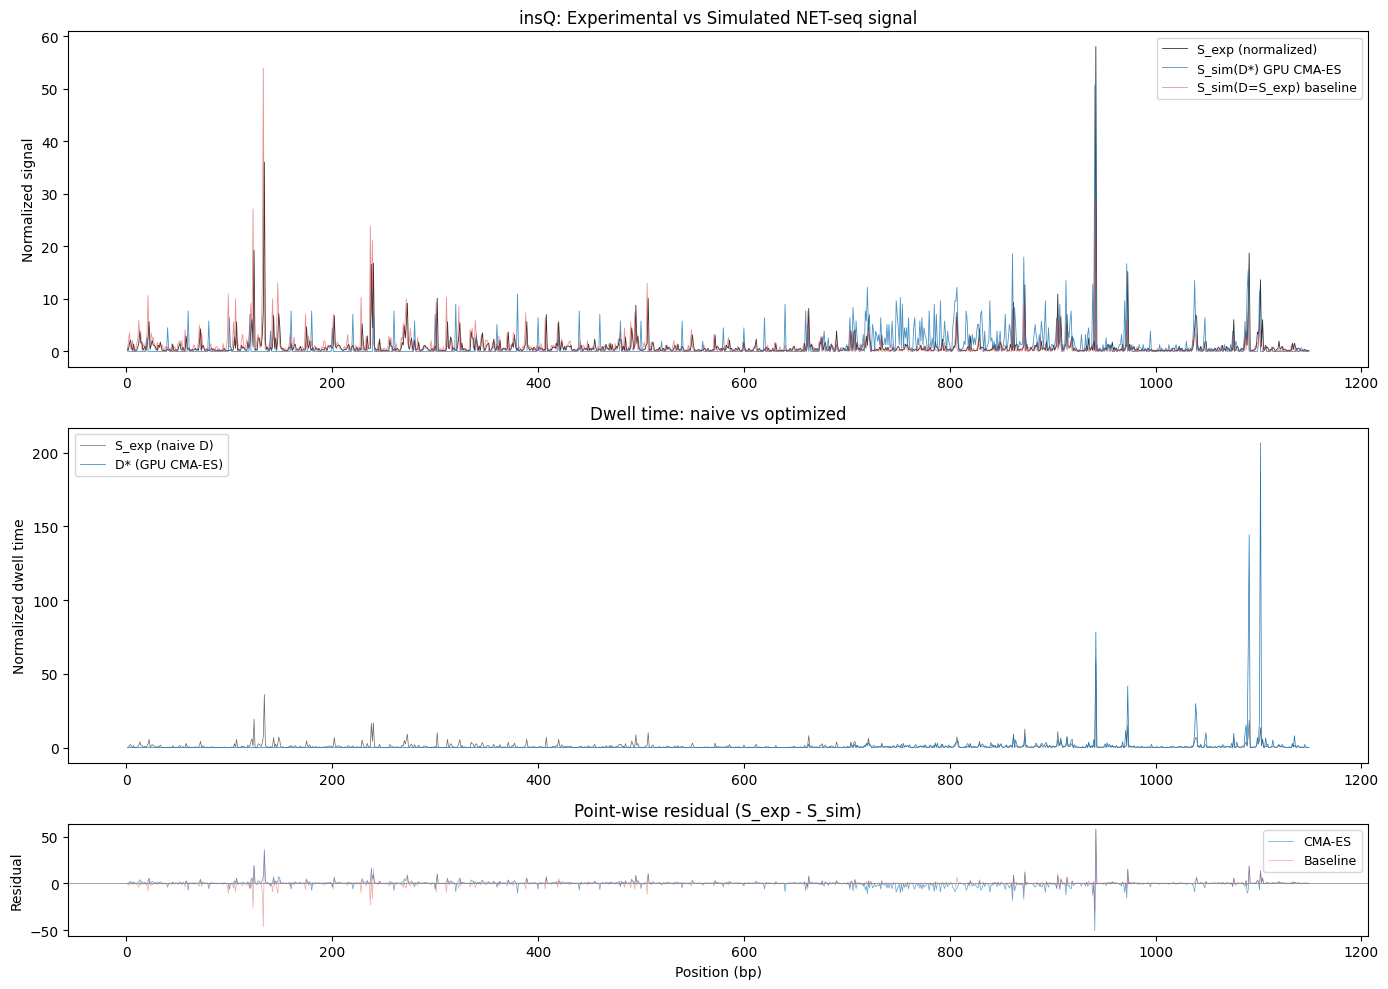

In [7]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), gridspec_kw={"height_ratios": [3, 3, 1]})

# S_exp vs S_sim(D*) vs baseline
axes[0].plot(pos, S_exp_norm, lw=0.6, color="black", label="S_exp (normalized)", alpha=0.8)
axes[0].plot(pos, S_sim_best_norm, lw=0.6, color="tab:blue", label="S_sim(D*) GPU CMA-ES", alpha=0.8)
axes[0].plot(pos, S_sim_baseline_norm, lw=0.6, color="tab:red", label="S_sim(D=S_exp) baseline", alpha=0.5)
axes[0].set_ylabel("Normalized signal")
axes[0].set_title(f"{GENE}: Experimental vs Simulated NET-seq signal")
axes[0].legend(fontsize=9)

# D* vs S_exp
axes[1].plot(pos, S_exp_norm, lw=0.5, color="black", label="S_exp (naive D)", alpha=0.6)
axes[1].plot(pos, D_best, lw=0.5, color="tab:blue", label="D* (GPU CMA-ES)")
axes[1].set_ylabel("Normalized dwell time")
axes[1].set_title("Dwell time: naive vs optimized")
axes[1].legend(fontsize=9)

# Residuals
axes[2].plot(pos, S_exp_norm - S_sim_best_norm, lw=0.5, color="tab:blue", alpha=0.7, label="CMA-ES")
axes[2].plot(pos, S_exp_norm - S_sim_baseline_norm, lw=0.5, color="tab:red", alpha=0.4, label="Baseline")
axes[2].axhline(0, color="gray", ls="-", lw=0.5)
axes[2].set_xlabel("Position (bp)")
axes[2].set_ylabel("Residual")
axes[2].set_title("Point-wise residual (S_exp - S_sim)")
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.show()

## Implied Flux Profile

Compare simulated flux $j_\text{sim}(x)$ against the analytical Gaussian model.

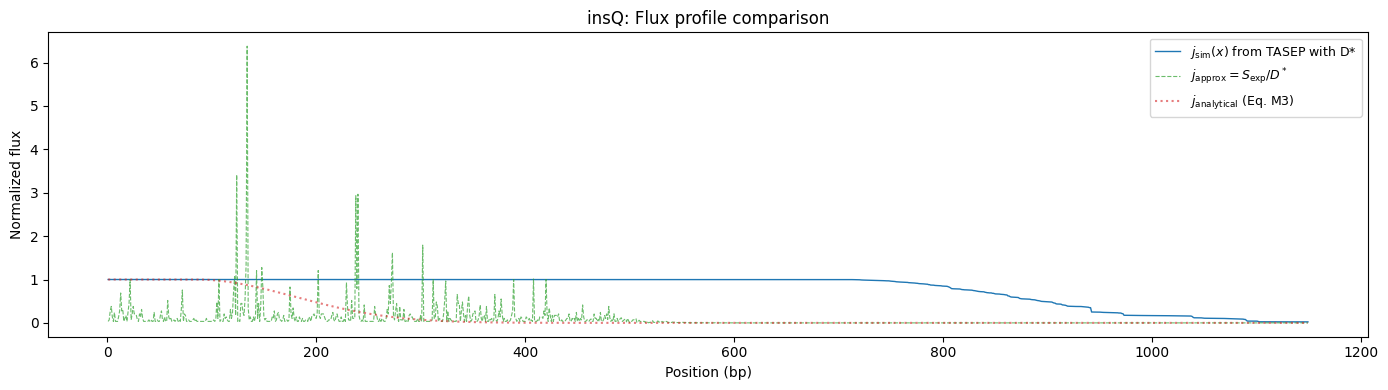

In [8]:
j_sim_norm = j_sim / np.max(j_sim[:100])
j_approx = S_exp_norm / np.maximum(D_best, 1e-6)
j_approx_norm = j_approx / np.max(j_approx[:100])

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(pos, j_sim_norm, lw=1.0, color="tab:blue", label=r"$j_\mathrm{sim}(x)$ from TASEP with D*")
ax.plot(pos, j_approx_norm, lw=0.8, color="tab:green", ls="--", alpha=0.7,
        label=r"$j_\mathrm{approx} = S_\mathrm{exp} / D^*$")
ax.plot(pos, j_anal, lw=1.5, color="tab:red", ls=":", alpha=0.6,
        label=r"$j_\mathrm{analytical}$ (Eq. M3)")
ax.set_xlabel("Position (bp)")
ax.set_ylabel("Normalized flux")
ax.set_title(f"{GENE}: Flux profile comparison")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()